# Basic Neural Network

IDEAS:

test RELU vs sigmoid

cross entry vs (y_true - y_pred)^2

check mini batches -  so compare decenet after every pic vs after whole data set vs mini batches

and also try to draw path to minimum in 3D

In [1]:
import idx2numpy
import numpy as np
import numpy.linalg as la

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 3)

In [2]:
# (60000, 28, 28) images, (60000,) labels
images_2d = idx2numpy.convert_from_file("../data/train-images.idx3-ubyte")
images = images_2d.reshape(images_2d.shape[0], -1)
labels = idx2numpy.convert_from_file("../data/train-labels.idx1-ubyte")

test_images_2d = idx2numpy.convert_from_file("../data/t10k-images.idx3-ubyte")
test_images = test_images_2d.reshape(test_images_2d.shape[0], -1)
test_labels = idx2numpy.convert_from_file("../data/t10k-labels.idx1-ubyte")

Labels: [5 0 4 1 9]


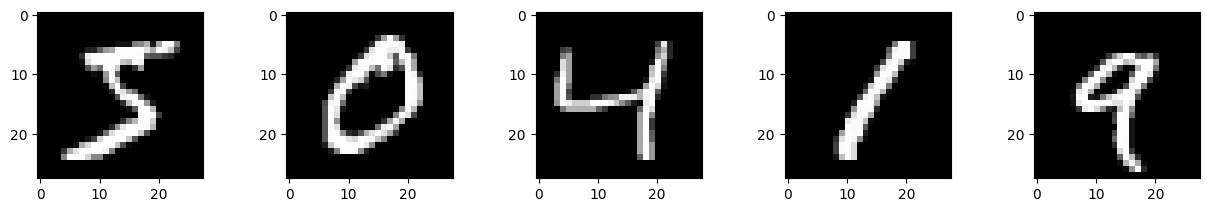

In [3]:
images_shown = 5

print("Labels:", labels[:images_shown])

f, axes = plt.subplots(
    1,
    images_shown,
    figsize=(images_shown * 3, 3),
    gridspec_kw={"wspace": images_shown / 10},
)
for i, ax in enumerate(axes):
    ax.imshow(images_2d[i], cmap="gray")

## One Layer

In [4]:
output_layer_test = 16
weights_test = np.random.randn(output_layer_test, images.shape[1]) * .1
bias_test = np.random.randn(output_layer_test)

transform = weights_test @ images[0] + bias_test
output_test = 1 / (1 + np.exp(-transform))
output_test[0]

np.float64(3.041785458469592e-31)

# Multiple Layers

In [5]:
def calculate_layer(input: np.ndarray, weights: np.ndarray, bias: np.ndarray) -> np.ndarray:
    transform = weights @ input + bias
    output = 1 / (1 + np.exp(-transform))
    return output

In [31]:
middle_layer = 16
final_layer = 10

w_1 = np.random.randn(middle_layer, images.shape[1]) * 0.1
b_1 = np.random.randn(middle_layer) * 0.1
layer_1 = calculate_layer(
    images[0],
    w_1,
    b_1,
)
w_2 = np.random.randn(middle_layer, middle_layer) * 0.1
b_2 = np.random.randn(middle_layer) * 0.1
layer_2 = calculate_layer(
    layer_1,
    w_2,
    b_2,
)
w_3 = np.random.randn(final_layer, middle_layer) * 0.1
b_3 = np.random.randn(final_layer) * 0.1
final_layer = calculate_layer(
    layer_2,
    w_3,
    b_3,
)
final_layer

array([0.5428583 , 0.54445693, 0.324224  , 0.60360131, 0.45989844,
       0.51018834, 0.55233893, 0.48392543, 0.43863628, 0.53096397])

In [32]:
print(np.argmax(final_layer))
print(labels[0])

3
5


Gave wrong answer as weights are completely random

In [33]:
cost = np.mean(np.square(final_layer - np.eye(10)[labels[0]]))
cost

np.float64(0.2525592893706158)

## Backpropagation

We're trying to find the change of the cost based of the weights $ = \frac{\partial C}{\partial w}$. Or the gradient would say the movement of the weights that would create the biggest change in the cost.

Due to chain rule it turns into $\frac{\partial C}{\partial w} = \frac{\partial z}{\partial w}\frac{\partial a}{\partial z}\frac{\partial C}{\partial a}$ since $z_n = w_n a_{n-1} + b$ and $a_n = \sigma(z_n)$

$C = (a - y)^2$ where $\frac{\partial C}{\partial a} = 2(a - y)$

$a = \sigma(z)$ where $\frac{\partial a}{\partial z} = \sigma'(z)$ here $\sigma(z) = \frac{1}{1+e^{-x}}$ which is $\sigma'(z) = \sigma(z) * (1 - \sigma(z))$

$z = w * a + b$ where $\frac{\partial z}{\partial w} = a$

$\frac{\partial C}{\partial w} = a_{n-1} * \sigma'(z_n) * 2(a_n - y)$

One row manually

In [ ]:
d_cost = 2 * (final_layer - np.eye(10)[labels[0]])

z_3 = w_3 @ layer_2 + b_3
d_sigma3 = (1 / (1 + np.exp(-z_3))) * (1 - (1 / (1 + np.exp(-z_3))))

z_2 = w_2 @ layer_1 + b_2
d_sigma2 = (1 / (1 + np.exp(-z_2))) * (1 - (1 / (1 + np.exp(-z_2))))

z_1 = w_1 @ images[0] + b_1
d_sigma1 = (1 / (1 + np.exp(-z_1))) * (1 - (1 / (1 + np.exp(-z_1))))

Though it would be dc_dw = images[0] @ d_sigma1 @ d_sigma2 * d_sigma1

But the matrix and vectors don't line up

I kinda understand it a bit better now the final layer C is the cost

the cost here is (y - a)^2 or the difference between what it actually is and what it should be

we had the solution here be 5 and we got a different number so for a single neuron that is not 5 we would do (y - 0)^2 where y is value of that specific neuron

so based of that scalar cost value we know for that neuron all the weights attatched should changes based of that value and it works since a stronger weight is going to change stronger than a weaker weight

so dc/da is going to be vector with component of scalar and so is $\sigma'$ then we end up multipliying thoese so here in the last layer we have 10 elements each and for each one we need to multiply row wise and create another 10 element vector

then we next otuput should give us our change in weights. Basically this cost (and sigma) basically gives us how to change the w values. We multipply by the preivous layer and not straight to w which is what I was thinking but what if the previous layer didn't even activate the neuron so the weight was never used. so past how much the weight should change we should check how much that neuron was also used.

so we end up getting a matrix where each vector is the previous layer multiplied by the cost to get the change in weight matrix. So we probably need to do outer product to get a matrix.

In [58]:
print((d_cost))
print((d_cost).shape)

[ 1.0857166   1.08891386  0.64844799  1.20720262  0.91979688 -0.97962331
  1.10467786  0.96785086  0.87727255  1.06192794]
(10,)


In [68]:
print((d_sigma3))
print((d_sigma3).shape)

[0.24816317 0.24802358 0.2191028  0.23926677 0.24839186 0.2498962
 0.24726064 0.24974161 0.24623449 0.24904123]
(10,)


In [71]:
print((d_sigma3 * d_cost))
print((d_sigma3 * d_cost).shape)

[ 0.26943487  0.27007632  0.14207677  0.28884347  0.22847006 -0.24480414
  0.27314335  0.24171263  0.21601476  0.26446384]
(10,)


In [72]:
print((layer_2))
print((layer_2).shape)

[0.42748327 0.50387086 0.46863964 0.47899829 0.45918561 0.46780039
 0.44688684 0.4911542  0.68582863 0.48630404 0.49804496 0.47007209
 0.41815894 0.40302265 0.56764225 0.57426802]
(16,)


In [86]:
print(np.outer(layer_2, (d_sigma3 * d_cost))[0])
print((np.outer(layer_2, (d_sigma3 * d_cost))).shape)

[ 0.1151789   0.11545311  0.06073544  0.12347575  0.09766713 -0.10464968
  0.11676421  0.10332811  0.0923427   0.11305387]
(16, 10)


This works and finally makes sense but I also reallized that we have to take this new dc/dw or change in weight based of the cost and compute the previous layer.

So we need to actually find the dc/da for the next layer to use like we did at the start. So we are actually find dc/da till the last layers

$\frac{\partial C_0}{\partial w^{(L-1)}} = \frac{\partial z^{(L-1)}}{\partial w^{(L-1)}} \frac{\partial a^{(L-1)}}{\partial z^{(L-1)}} \frac{\partial z^{(L)}}{\partial a^{(L-1)}} \frac{\partial a^{(L)}}{\partial z^{(L)}} \frac{\partial C_0}{\partial a^{(L)}}$

here the dc/da becomes the weights also we need to tranpose the weight since it usually is 784 by 100 but we need to go to 100 by 784

In [80]:
print(np.outer(w_3, (d_sigma3 * d_cost).T)[0])
print((np.outer(w_3, (d_sigma3 * d_cost).T)).shape)

[ 0.02737818  0.02744336  0.0144369   0.02935035  0.02321561 -0.02487537
  0.02775501  0.02456123  0.02194999  0.02687306]
(160, 10)


In [99]:
print((w_3.T @ (d_sigma3 * d_cost))[0])
print((w_3.T @ (d_sigma3 * d_cost)).shape)

0.03375934973853483
(16,)


This vector we just keep going with to the intial weight change also fixed the outer since we were getting 728 by 16 but the actual weights are 16 by 728 since (16 * 728) * (728, 1) whcih is input gives us the second layer of 16 neurons.

In [101]:
a_3_change = w_3.T @ (d_sigma3 * d_cost)
a_2_change = w_2.T @ (d_sigma2 * a_3_change)
w_1_change = np.outer((d_sigma1 * a_2_change), images[0])
b_1_change = (d_sigma1 * a_2_change)
w_1_change.shape

(16, 784)

In [114]:
learning_rate = 1

w_1_new = w_1 - (learning_rate * w_1_change)
b_1_new = b_1 - (learning_rate * b_1_change)

w_2_new = w_2 - (learning_rate * np.outer((d_sigma2 * a_3_change), layer_1))
b_2_new = b_2 - (learning_rate * (d_sigma2 * a_3_change))

w_3_new = w_3 - (learning_rate * np.outer((d_sigma3 * d_cost), layer_2))
b_3_new = b_3 - (learning_rate * (d_sigma3 * d_cost))

In [115]:
layer_1_new = calculate_layer(
    images[0],
    w_1_new,
    b_1_new,
)
layer_2_new = calculate_layer(
    layer_1_new,
    w_2_new,
    b_2_new,
)
final_layer_new = calculate_layer(
    layer_2_new,
    w_3_new,
    b_3_new,
)
final_layer_new

array([0.23826977, 0.23907082, 0.1956452 , 0.26488227, 0.2130369 ,
       0.77567593, 0.24097805, 0.21728575, 0.21045939, 0.23336035])

In [116]:
print(np.argmax(final_layer_new))
print(labels[0])

5
5


It actually worked with a pretty high learning score butu should set it low in the future if we're doing multiple numbers

# Actual Code

In [123]:
def sigmoid(x: np.ndarray):
    return 1 / (1 + np.exp(-x))

def d_sigmoid(x: np.ndarray):
    return sigmoid(x) * (1 - sigmoid(x))

In [124]:
def neural_step(input_data: np.ndarray, label: int, weights: list[np.ndarray], biases: list[np.ndarray], learning_rate: float):
    W1, W2, W3 = weights
    b1, b2, b3 = biases

    z1 = W1 @ input_data + b1
    a1 = sigmoid(z1)
    z2 = W2 @ a1 + b2
    a2 = sigmoid(z2)
    z3 = W3 @ a2 + b3
    a3 = sigmoid(z3)

    d_c = 2 * (a3 - np.eye(10)[label])

    delta3 = d_sigmoid(z3) * d_c
    a3_n = W3.T @ delta3
    W3_N = W3 - (learning_rate * np.outer(delta3, a2))
    b3_n = b3 - (learning_rate * delta3)

    delta2 = d_sigmoid(z2) * a3_n
    a2_n = W2.T @ delta2
    W2_N = W2 - (learning_rate * np.outer(delta2, a1))
    b2_n = b2 - (learning_rate * delta2)

    delta1 = d_sigmoid(z1) * a2_n
    W1_N = W1 - (learning_rate * np.outer(delta1, input_data))
    b1_n = b1 - (learning_rate * delta1)

    return ([W1_N, W2_N, W3_N], [b1_n, b2_n, b3_n])

In [164]:
images_scale = images / 255

In [ ]:
W1 = np.random.randn(16, 784) * 0.01
W2 = np.random.randn(16, 16) * 0.01
W3 = np.random.randn(10, 16) * 0.01

b1 = np.zeros(16)
b2 = np.zeros(16)
b3 = np.zeros(10)

for i in range(len(images_scale)):
    (W1, W2, W3), (b1, b2, b3) = neural_step(images_scale[i], labels[i], 
                [W1, W2, W3],
                [b1, b2, b3],
                .1)


In [ ]:
test_image = images_scale[1]

z1 = W1 @ test_image + b1
a1 = sigmoid(z1)
z2 = W2 @ a1 + b2
a2 = sigmoid(z2)
z3 = W3 @ a2 + b3
a3 = sigmoid(z3)

print(np.argmax(a3))
print(labels[1])

0
0


In [187]:
test_images_scale = test_images / 255.0

In [188]:
output = np.array([])

for i in range(len(test_images_scale)):
    test_image = test_images_scale[i]

    z1 = W1 @ test_image + b1
    a1 = sigmoid(z1)
    z2 = W2 @ a1 + b2
    a2 = sigmoid(z2)
    z3 = W3 @ a2 + b3
    a3 = sigmoid(z3)

    output = np.append(output, np.argmax(a3))

In [199]:
print(output[:10].astype(int))
print(test_labels[:10])

[7 2 1 0 4 1 4 9 6 9]
[7 2 1 0 4 1 4 9 5 9]


In [201]:
matches = output == test_labels
correct_count = np.sum(matches)
total_count = len(test_labels)

print(f"Correct predictions: {correct_count} out of {total_count}")
print(f"Accuracy: {correct_count / total_count * 100:.2f}%")

plain_accuracy = correct_count / total_count * 100

Correct predictions: 7856 out of 10000
Accuracy: 78.56%
